# A. SIMPLE 3D CNN MODEL FROM Pytorch

## Bài tập 1

In [2]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [3]:
from dataset import get_dataloaders
from cnn3d import SimpleCNN3D

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [5]:
data_root = "./dataset/UCF50"
batch_size = 32
num_frames = 16
img_size = 112
epochs = 50
learning_rate = 3e-4

train_loader, val_loader, class_to_idx = get_dataloaders(
    data_root=data_root,
    batch_size=batch_size,
    num_frames=num_frames,
    img_size=img_size,
    output_format="CTHW",
    split_ratio=0.8,
    num_workers=8
)

num_classes = len(class_to_idx)
print("Classes:", num_classes)
print("Train samples:", len(train_loader.dataset))
print("Val samples:", len(val_loader.dataset))

Classes: 50
Train samples: 5326
Val samples: 1355


In [6]:
torch.backends.cudnn.benchmark = True

model = SimpleCNN3D(num_classes=num_classes)

if torch.cuda.device_count() > 1:
    print(f"Sử dụng {torch.cuda.device_count()} GPUs!")
    model = nn.DataParallel(model)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
scaler = torch.cuda.amp.GradScaler()

Sử dụng 2 GPUs!


/tmp/ipykernel_4079659/2751909002.py:13: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [7]:
# history = {
#     "train_loss": [], "train_acc": [],
#     "val_loss": [], "val_acc": []
# }

# best_val_acc = 0.0

# for epoch in range(epochs):
#     model.train()
#     train_loss = 0.0
#     train_correct = 0
#     total_train = 0

#     for inputs, targets in train_loader:
#         inputs, targets = inputs.to(device, non_blocking=True), targets.to(device, non_blocking=True)

#         optimizer.zero_grad()
#         with torch.cuda.amp.autocast():
#             outputs = model(inputs)
#             loss = criterion(outputs, targets)

#         scaler.scale(loss).backward()
#         scaler.step(optimizer)
#         scaler.update()

#         train_loss += loss.item() * inputs.size(0)
#         _, preds = torch.max(outputs, 1)
#         train_correct += (preds == targets).sum().item()
#         total_train += targets.size(0)

#     epoch_train_loss = train_loss / total_train
#     epoch_train_acc = train_correct / total_train

#     model.eval()
#     val_loss = 0.0
#     val_correct = 0
#     total_val = 0

#     with torch.no_grad():
#         for inputs, targets in val_loader:
#             inputs, targets = inputs.to(device, non_blocking=True), targets.to(device, non_blocking=True)

#             with torch.cuda.amp.autocast():
#                 outputs = model(inputs)
#                 loss = criterion(outputs, targets)

#             val_loss += loss.item() * inputs.size(0)
#             _, preds = torch.max(outputs, 1)
#             val_correct += (preds == targets).sum().item()
#             total_val += targets.size(0)

#     epoch_val_loss = val_loss / total_val
#     epoch_val_acc = val_correct / total_val

#     history["train_loss"].append(epoch_train_loss)
#     history["train_acc"].append(epoch_train_acc)
#     history["val_loss"].append(epoch_val_loss)
#     history["val_acc"].append(epoch_val_acc)

#     print(f"Epoch [{epoch+1:02d}/{epochs:02d}] "
#           f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc*100:.2f}% | "
#           f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc*100:.2f}%")

#     if epoch_val_acc > best_val_acc:
#         best_val_acc = epoch_val_acc
#         save_state = model.module.state_dict() if hasattr(model, "module") else model.state_dict()
#         torch.save(save_state, "best_cnn3d.pth")

In [8]:
checkpoint_path = "best_cnn3d.pth"
if os.path.exists(checkpoint_path):
    target_model = model.module if hasattr(model, "module") else model
    target_model.load_state_dict(torch.load(checkpoint_path, map_location=device))

history = {
    "train_loss": [
        3.8270, 3.4977, 3.2597, 3.0564, 2.8510, 2.6909, 2.5452, 2.4286, 
        2.3312, 2.2353, 2.1423, 2.0577, 1.9873, 1.8848, 1.8196, 1.7543, 
        1.6912, 1.6235, 1.5418, 1.4987, 1.4323, 1.3682
    ],
    "train_acc": [
        0.0413, 0.1127, 0.1478, 0.1943, 0.2332, 0.2640, 0.2978, 0.3267, 
        0.3500, 0.3719, 0.3851, 0.4125, 0.4260, 0.4668, 0.4807, 0.4951, 
        0.5163, 0.5314, 0.5522, 0.5704, 0.5843, 0.6025
    ],
    "val_loss": [
        3.6311, 3.3381, 3.1577, 2.9460, 2.7633, 2.6446, 2.5111, 2.4390, 
        2.3286, 2.2400, 2.2012, 2.1977, 2.0694, 2.0455, 1.9913, 1.9147, 
        1.9168, 1.8386, 1.7833, 1.8422, 1.7089, 1.6773
    ],
    "val_acc": [
        0.0790, 0.1284, 0.1572, 0.2022, 0.2494, 0.2731, 0.3011, 0.3247, 
        0.3638, 0.3911, 0.3860, 0.3963, 0.4258, 0.4258, 0.4524, 0.4554, 
        0.4716, 0.4923, 0.5092, 0.4937, 0.5446, 0.5306
    ]
}

best_val_acc = 0.5446
start_epoch = len(history["train_loss"])

for epoch in range(start_epoch, epochs):
    model.train()
    train_loss = 0.0
    train_correct = 0
    total_train = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device, non_blocking=True), targets.to(device, non_blocking=True)

        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            outputs = model(inputs)
            loss = criterion(outputs, targets)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        train_correct += (preds == targets).sum().item()
        total_train += targets.size(0)

    epoch_train_loss = train_loss / total_train
    epoch_train_acc = train_correct / total_train

    model.eval()
    val_loss = 0.0
    val_correct = 0
    total_val = 0

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device, non_blocking=True), targets.to(device, non_blocking=True)

            with torch.amp.autocast('cuda'):
                outputs = model(inputs)
                loss = criterion(outputs, targets)

            val_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == targets).sum().item()
            total_val += targets.size(0)

    epoch_val_loss = val_loss / total_val
    epoch_val_acc = val_correct / total_val

    history["train_loss"].append(epoch_train_loss)
    history["train_acc"].append(epoch_train_acc)
    history["val_loss"].append(epoch_val_loss)
    history["val_acc"].append(epoch_val_acc)

    print(f"Epoch [{epoch+1:02d}/{epochs:02d}] "
          f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc*100:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc*100:.2f}%")

    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        save_state = model.module.state_dict() if hasattr(model, "module") else model.state_dict()
        torch.save(save_state, "best_cnn3d.pth")


Epoch [23/50] Train Loss: 0.7862 | Train Acc: 76.14% | Val Loss: 1.3394 | Val Acc: 64.06%
Epoch [24/50] Train Loss: 0.7375 | Train Acc: 77.41% | Val Loss: 1.2922 | Val Acc: 65.61%
Epoch [25/50] Train Loss: 0.7203 | Train Acc: 77.54% | Val Loss: 1.2961 | Val Acc: 66.64%
Epoch [26/50] Train Loss: 0.6919 | Train Acc: 78.97% | Val Loss: 1.2830 | Val Acc: 65.54%
Epoch [27/50] Train Loss: 0.6800 | Train Acc: 79.22% | Val Loss: 1.3158 | Val Acc: 66.57%
Epoch [28/50] Train Loss: 0.6342 | Train Acc: 81.30% | Val Loss: 1.2851 | Val Acc: 68.41%
Epoch [29/50] Train Loss: 0.6143 | Train Acc: 81.21% | Val Loss: 1.2350 | Val Acc: 69.96%
Epoch [30/50] Train Loss: 0.5963 | Train Acc: 81.77% | Val Loss: 1.2340 | Val Acc: 68.41%
Epoch [31/50] Train Loss: 0.5695 | Train Acc: 82.88% | Val Loss: 1.2480 | Val Acc: 68.27%
Epoch [32/50] Train Loss: 0.5571 | Train Acc: 83.12% | Val Loss: 1.2534 | Val Acc: 68.63%
Epoch [33/50] Train Loss: 0.5385 | Train Acc: 82.75% | Val Loss: 1.1663 | Val Acc: 71.14%
Epoch [34/

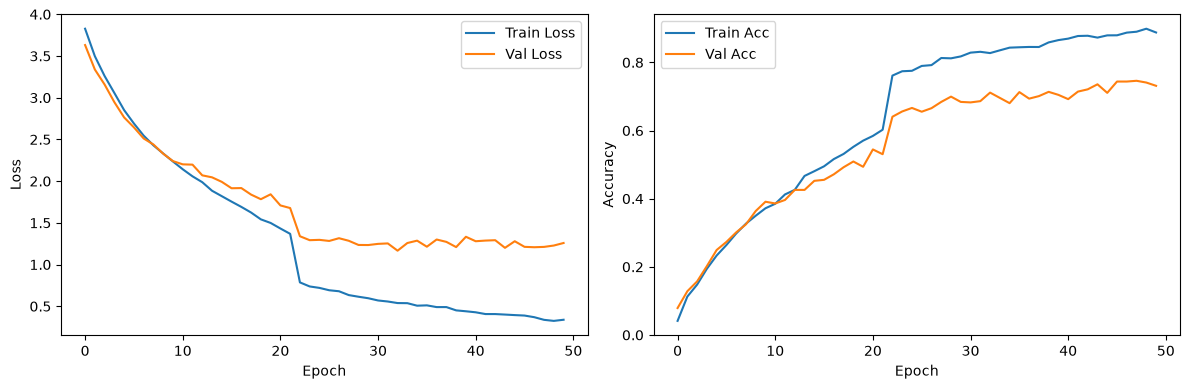

In [9]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history["train_acc"], label="Train Acc")
plt.plot(history["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.savefig("loss_acc_curve.png")
plt.show()